In [1]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, GRU , SimpleRNN

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
df = pd.read_csv('combined_data.csv')

In [5]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [6]:
df.isnull().sum()

,0
label,0
text,0


In [7]:
df.shape

(8841, 2)

In [8]:
df['text'] = df['text'].str.lower()

In [9]:
def remove_special(text):
  return text.translate (str.maketrans('', '', string.punctuation))

df['text'] = df['text'].apply(remove_special)

In [10]:
Stops = set(stopwords.words('english'))

In [11]:
def  remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)
df['text'] = df['text'].apply(remove_stopwords)




In [12]:
df.head()

,label,text
0,1,"[ounce, feather, bowl, hummingbird, opec, mome..."
1,1,"[wulvob, get, medircations, online, qnb, ikud,..."
2,0,"[computer, connection, cnn, com, wednesday, es..."
3,1,"[university, degree, obtain, prosperous, futur..."
4,0,"[thanks, answers, guys, know, checked, rsync, ..."


In [13]:
df['text'] = df['text'].apply(' '.join)

In [14]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [15]:
def remove_hyperlink(word):
    return re.sub(r"http\S+", "", word)

df['text'] = df['text'].apply(remove_hyperlink)

In [16]:
import pandas as pd
import re
from collections import Counter

# 1. Filter only spam emails
spam_df = df[df['label'] == 1]   # change to == 1 if spam is labeled as 1

# 2. Combine all spam text into one string
all_spam_text = " ".join(spam_df['text'])

# 3. Clean text (lowercase, remove special characters & numbers)
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)

# 4. Split into words
words = all_spam_text.split()

# 5. Count word frequencies
word_freq = Counter(words)

# 6. Get Top 10 most common words
top_10_words = word_freq.most_common(10)

print("Top 10 most frequent words in SPAM emails:")
for word, freq in top_10_words:
    print(f"{word} : {freq}")


Top 10 most frequent words in SPAM emails:
escapenumber : 38382
escapelong : 18349
per : 3539
com : 3533
pills : 3272
x : 3185
escapenumbermg : 2887
http : 2873
save : 2139
item : 2085


In [17]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [18]:
max_features = 5000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [19]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)

In [21]:
average_length

140.5823062637177

In [22]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,padding = 'post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,padding = 'post')

In [25]:
max_features = 5000
max_length = 500
embedding_length = 32

In [26]:
model_rnn = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 498,821 (1.90 MB)

 Trainable params: 166,273 (649.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 332,548 (1.27 MB)

In [37]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
EPOCHS = 10
BATCH_SIZE = 64

In [30]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7859 - loss: 0.4513 - val_accuracy: 0.8914 - val_loss: 0.2681
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9652 - loss: 0.1198 - val_accuracy: 0.9417 - val_loss: 0.1727
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9792 - loss: 0.0785 - val_accuracy: 0.9688 - val_loss: 0.1007
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9916 - loss: 0.0356 - val_accuracy: 0.9740 - val_loss: 0.0921
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9961 - loss: 0.0204 - val_accuracy: 0.9637 - val_loss: 0.1128
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9976 - loss: 0.0129 - val_accuracy: 0.9733 - val_loss: 0.0941
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9988 - loss: 0.0095 - val_accuracy: 0.9746 - val_loss: 0.0940
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9986 - loss: 0.0090 - val_accuracy: 0.9722 - 

In [39]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.8874 - loss: 0.3235 - val_accuracy: 0.9510 - val_loss: 0.1769
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9779 - loss: 0.0972 - val_accuracy: 0.9705 - val_loss: 0.0991
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9575 - loss: 0.2210 - val_accuracy: 0.9003 - val_loss: 0.3517
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9298 - loss: 0.2152 - val_accuracy: 0.8968 - val_loss: 0.2614
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9634 - loss: 0.1118 - val_accuracy: 0.9568 - val_loss: 0.1395
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9858 - loss: 0.0505 - val_accuracy: 0.9698 - val_loss: 0.1042
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9922 - loss: 0.0313 - val_accuracy: 0.9743 - val_loss: 0.0904
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9949 - loss: 0.0220 - val_accuracy: 0.9712 - 

In [40]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.8683 - loss: 0.3187 - val_accuracy: 0.9685 - val_loss: 0.1225
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9728 - loss: 0.0983 - val_accuracy: 0.9798 - val_loss: 0.0781
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9863 - loss: 0.0601 - val_accuracy: 0.9740 - val_loss: 0.0973
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9895 - loss: 0.0407 - val_accuracy: 0.9740 - val_loss: 0.0806
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9931 - loss: 0.0261 - val_accuracy: 0.9753 - val_loss: 0.0803
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9943 - loss: 0.0236 - val_accuracy: 0.9726 - val_loss: 0.0943
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9929 - loss: 0.0232 - val_accuracy: 0.9740 - val_loss: 0.0878
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9965 - loss: 0.0170 - val_accuracy: 0.9750 - 

In [41]:
import numpy as np

y_pred_rnn = np.round(model_rnn.predict(X_test_pad))
y_pred_lstm = np.round(model_lstm.predict(X_test_pad))
y_pred_gru = np.round(model_gru.predict(X_test_pad))

y_p_rnn = (y_pred_rnn > 0.5).astype(int)
y_p_lstm = (y_pred_lstm > 0.5).astype(int)
y_p_gru = (y_pred_gru > 0.5).astype(int)

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


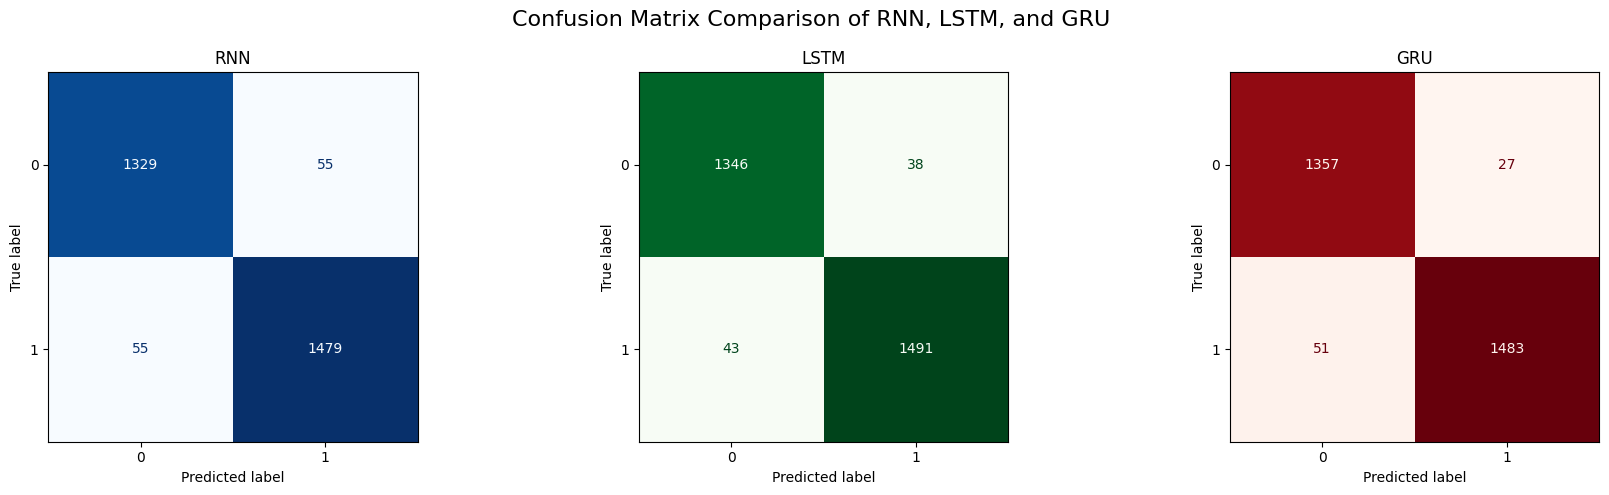

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrices
cm_rnn = confusion_matrix(y_test, y_p_rnn)
cm_lstm = confusion_matrix(y_test, y_p_lstm)
cm_gru = confusion_matrix(y_test, y_p_gru)

# Create one figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RNN
ConfusionMatrixDisplay(cm_rnn).plot(
    cmap='Blues',
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("RNN")

# LSTM
ConfusionMatrixDisplay(cm_lstm).plot(
    cmap='Greens',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("LSTM")

# GRU
ConfusionMatrixDisplay(cm_gru).plot(
    cmap='Reds',
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("GRU")

plt.suptitle("Confusion Matrix Comparison of RNN, LSTM, and GRU", fontsize=16)
plt.tight_layout()
plt.show()

In [46]:
print('RNN Model Accuracy:', accuracy_score(y_test, y_p_rnn))
print('LSTM Model Accuracy:', accuracy_score(y_test, y_p_lstm))
print('GRU Model Accuracy:', accuracy_score(y_test, y_p_gru))

RNN Model Accuracy: 0.9623029472241261
LSTM Model Accuracy: 0.9722412611377655
GRU Model Accuracy: 0.9732693625771076


### Classification Reports

In [47]:
print('RNN Model Classification Report:')
print(classification_report(y_test, y_p_rnn))

print('\nLSTM Model Classification Report:')
print(classification_report(y_test, y_p_lstm))

print('\nGRU Model Classification Report:')
print(classification_report(y_test, y_p_gru))

RNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1384
           1       0.96      0.96      0.96      1534

    accuracy                           0.96      2918
   macro avg       0.96      0.96      0.96      2918
weighted avg       0.96      0.96      0.96      2918


LSTM Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1384
           1       0.98      0.97      0.97      1534

    accuracy                           0.97      2918
   macro avg       0.97      0.97      0.97      2918
weighted avg       0.97      0.97      0.97      2918


GRU Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1384
           1       0.98      0.97      0.97      1534

    accuracy                           0.97      2918
   macro avg       0.97   

In [52]:
import pickle

# Save Model
model_gru.save("gru_spam_classifier.keras")

# Save Tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save Max Length
with open("max_len.pkl", "wb") as f:
    pickle.dump(max_length, f)

print("All files saved successfully!")

All files saved successfully!
